# Predicción de no-show en turnos médicos

**TPO de Ciencia de Datos — UADE, Grupo 7**

**Audiencia:** Gerencia Comercial y Técnica.
**Framework de trabajo:** CRISP-DM (Cross-Industry Standard Process for Data Mining).

Este notebook documenta el ciclo completo de análisis y modelado: comprensión del
negocio, comprensión y preparación de los datos, análisis exploratorio (EDA) con
storytelling orientado a negocio, modelado con Árbol de Decisión y Random Forest,
evaluación y conclusiones con sus limitaciones. Todo el código reutiliza los módulos
de `src/noshow/` (no se reimplementa lógica de negocio en el notebook); el notebook
la ejecuta, la visualiza y la interpreta.


## 1. Comprensión del negocio

### El problema

El ausentismo a turnos médicos ya agendados (**no-show**) es una fuente de ineficiencia
crónica en la operación de un centro de salud: una franja horaria del profesional queda
ociosa y, al mismo tiempo, otro paciente que sí habría asistido pierde la oportunidad de
ocupar ese lugar (lista de espera). Hoy la institución **no cuenta con información
anticipada** de qué turnos tienen alta probabilidad de no-show, por lo que no puede
actuar de forma preventiva (recordatorio reforzado, sobreturno controlado).

### Hipótesis de trabajo

- El no-show no es aleatorio: hay variables observables al momento de agendar el turno
  (anticipación con la que se agenda, edad del paciente, día de la semana, barrio,
  comorbilidades, y —como fuente secundaria— el clima del día del turno) que se
  correlacionan con la probabilidad de ausencia.
- Un modelo de clasificación entrenado sobre el historial de turnos puede estimar, al
  momento de agendar, la probabilidad de no-show de un turno nuevo con una capacidad de
  discriminación útil para la operación (aunque esté lejos de ser perfecta).

### Propuesta de valor

Si el modelo identifica con antelación los turnos de alto riesgo de no-show, la
institución puede:

1. Enviar un **recordatorio reforzado** (llamado telefónico, SMS adicional) a los turnos
   de riesgo medio/alto.
2. Ofrecer **sobreturnos controlados** en las franjas de riesgo más alto, recuperando
   horas-profesional que hoy quedan ociosas.
3. Priorizar la intervención humana (limitada) donde más impacto tiene, en vez de
   aplicarla de forma uniforme a todos los turnos.

El criterio de éxito no es una accuracy alta (engañosa bajo el desbalance de clases que
se documenta en la Sección 2), sino un modelo que **discrimine razonablemente bien
(ROC-AUC)** y que, ajustando el umbral de decisión al costo de negocio, logre un
**recall alto de la clase no-show** — es preferible reforzar el recordatorio a un turno
que igual iba a asistir (bajo costo) antes que dejar pasar un no-show real (alto costo:
la franja queda vacía y no se pudo reasignar a tiempo).


## 2. Comprensión de los datos

Fuente primaria: `no-show-dataset.csv` (Kaggle, turnos médicos de Vitória, ES — Brasil,
abril-junio de 2016). Se carga con `noshow.data_load.load_appointments`, que valida el
esquema de 14 columnas y normaliza el target `No-show` ("Yes"/"No") a una columna
binaria `no_show` (1 = faltó, 0 = asistió) junto con `target_name` (estilo cátedra).


In [1]:
import sys
from pathlib import Path

# Permite importar el paquete `noshow` (en `src/`) sin instalarlo, ejecutando el
# notebook desde `notebooks/` o desde la raíz del repo.
SRC_DIR = (Path.cwd() / ".." / "src").resolve() if Path.cwd().name == "notebooks" else (Path.cwd() / "src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
pd.set_option("display.max_columns", 40)

from noshow import config
from noshow.data_load import load_appointments

FIGURES_DIR = config.ROOT_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del repo: {config.ROOT_DIR}")
print(f"Figuras se exportan a: {FIGURES_DIR}")


Raíz del repo: /Users/fmartinezvidal/Documents/github/medical-noshow-prediction
Figuras se exportan a: /Users/fmartinezvidal/Documents/github/medical-noshow-prediction/reports/figures


In [2]:
df_raw = load_appointments()
df_raw.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,no_show,target_name
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,show
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,show
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,show
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,show
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,show


In [3]:
df_raw.shape

(110527, 16)

In [4]:
df_raw.dtypes

PatientId                     float64
AppointmentID                   int64
Gender                            str
ScheduledDay      datetime64[us, UTC]
AppointmentDay    datetime64[us, UTC]
Age                             int64
Neighbourhood                     str
Scholarship                     int64
Hipertension                    int64
Diabetes                        int64
Alcoholism                      int64
Handcap                         int64
SMS_received                    int64
No-show                           str
no_show                         int64
target_name                       str
dtype: object

In [5]:
df_raw.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
no_show           0
target_name       0
dtype: int64

In [6]:
df_raw.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,no_show
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,0.201933
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,0.401444
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000


**Lectura rápida de `.describe()`:**

- `Age` tiene un mínimo de **-1**: hay al menos un registro con edad inválida (se
  descarta en la etapa de limpieza, Sección 3).
- `PatientId`/`AppointmentID` son identificadores, no features predictivas — se excluyen
  del modelado (ver `noshow.preprocess.NON_FEATURE_COLUMNS`).
- `Scholarship`, `Hipertension`, `Diabetes`, `Alcoholism`, `SMS_received` son binarias
  (0/1); `Handcap` es un conteo de discapacidades (0 a 4). No hay valores nulos en
  ninguna columna (`.isnull().sum()` da 0 en todas), lo cual es consistente con un
  dataset de Kaggle ya relativamente curado — la limpieza real pasa por valores
  *inválidos* (edad/lead time negativos), no por *faltantes*.


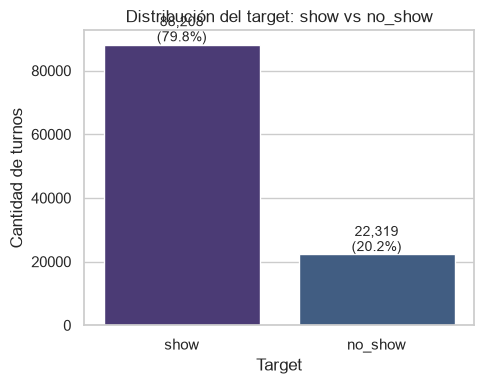

target_name
show       79.806744
no_show    20.193256
Name: proportion, dtype: float64

In [7]:
target_counts = df_raw["target_name"].value_counts()
target_pct = df_raw["target_name"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax, hue=target_counts.index, legend=False)
for i, (count, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, count + 1000, f"{count:,}\n({pct:.1f}%)", ha="center", fontsize=10)
ax.set_xlabel("Target")
ax.set_ylabel("Cantidad de turnos")
ax.set_title("Distribución del target: show vs no_show")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()

target_pct

**Interpretación — desbalance de clases:**

El target está **desbalanceado ~80/20**: el 79,8 % de los turnos se cumple (`show`) y
solo el **20,2 %** termina en `no_show` (22.319 de 110.527 turnos). Esto tiene dos
consecuencias directas para el resto del trabajo:

1. **La accuracy es una métrica engañosa**: un clasificador trivial que siempre prediga
   "show" acertaría ~80 % de las veces sin aportar ningún valor de negocio. Por eso el
   modelado (Sección 5) usa `StratifiedKFold` + F1/ROC-AUC de la clase minoritaria, y la
   evaluación (Sección 6) se apoya en `classification_report` y la matriz de confusión,
   no en accuracy.
2. **El split debe ser estratificado** (`train_test_split(..., stratify=y)`) para que
   train y test conserven la misma proporción de no-show que el dataset completo.


## 3. Preparación de los datos

Se agrega una **segunda fuente de datos** (clima horario INMET 2016, estación **A612 —
Vitória, ES**, la misma ciudad de origen de los turnos) para explorar si variables
climáticas del día del turno se asocian al no-show (¿llovió → faltó más gente?). El
clima horario se agrega a granularidad diaria (`noshow.weather.load_weather_daily`,
lectura por chunks del CSV crudo de 437 MB para no cargarlo completo en memoria) y se
cruza con los turnos por `AppointmentDay` (`noshow.weather.merge_weather`).

Luego se aplica la ingeniería de características (`noshow.features.build_features`):
`lead_time_days`, día de semana/mes del turno, `same_day`, grupo etario (`age_group`),
conteo/indicador de comorbilidades y agrupamiento de barrios de baja frecuencia
(`neighbourhood_grouped`). Todo el pipeline queda orquestado en
`noshow.features.build_processed_dataset`, que cachea el resultado en
`data/processed/appointments_processed.csv`.


In [8]:
from noshow.weather import load_weather_daily, merge_weather

weather_daily = load_weather_daily()
print(f"Clima diario (estación {config.WEATHER_STATION}): {weather_daily.shape}")
weather_daily.head()

Clima diario (estación A612): (366, 7)


,date,precipitation_mm,temp_max,temp_min,temp_mean,humidity_mean,is_rainy
0,2016-01-01,0.0,36.1,24.8,29.033333,65.333333,0
1,2016-01-02,1.2,33.0,24.3,28.054167,68.916667,1
2,2016-01-03,29.8,28.8,23.9,25.304167,86.958333,1
3,2016-01-04,8.6,29.0,23.6,25.637500,75.541667,1
4,2016-01-05,4.6,30.2,22.4,25.420833,72.666667,1


In [9]:
merged = merge_weather(df_raw, weather_daily)
print(f"Turnos sin clima disponible para su fecha (weather_missing=1): {int(merged['weather_missing'].sum())}")
merged[["AppointmentDay", "precipitation_mm", "temp_mean", "humidity_mean", "is_rainy", "weather_missing"]].head()

Turnos sin clima disponible para su fecha (weather_missing=1): 0


,AppointmentDay,precipitation_mm,temp_mean,humidity_mean,is_rainy,weather_missing
0,2016-04-29 00:00:00+00:00,0.2,22.65,73.208333,1,0
1,2016-04-29 00:00:00+00:00,0.2,22.65,73.208333,1,0
2,2016-04-29 00:00:00+00:00,0.2,22.65,73.208333,1,0
3,2016-04-29 00:00:00+00:00,0.2,22.65,73.208333,1,0
4,2016-04-29 00:00:00+00:00,0.2,22.65,73.208333,1,0


In [10]:
from noshow.features import build_features

df = build_features(merged)
print(f"Filas antes de limpiar inválidos: {len(df_raw):,}")
print(f"Filas después de features + limpieza: {len(df):,}  (se descartan {len(df_raw) - len(df)} registros con Age o lead_time_days negativos)")
print(f"Barrios: {df_raw['Neighbourhood'].nunique()} originales -> {df['neighbourhood_grouped'].nunique()} agrupados (umbral de frecuencia mínima)")
df[["lead_time_days", "appointment_dow", "appointment_month", "same_day", "age_group", "comorbidity_count", "has_comorbidity", "neighbourhood_grouped"]].head()

Filas antes de limpiar inválidos: 110,527
Filas después de features + limpieza: 110,521  (se descartan 6 registros con Age o lead_time_days negativos)
Barrios: 81 originales -> 36 agrupados (umbral de frecuencia mínima)


,lead_time_days,appointment_dow,appointment_month,same_day,age_group,comorbidity_count,has_comorbidity,neighbourhood_grouped
0,0,4,4,1,adulto,1,1,JARDIM DA PENHA
1,0,4,4,1,adulto,0,0,JARDIM DA PENHA
2,0,4,4,1,adulto,0,0,OTHER
3,0,4,4,1,menor,0,0,OTHER
4,0,4,4,1,adulto,2,1,JARDIM DA PENHA


In [11]:
from noshow.features import build_processed_dataset

# Reutiliza el dataset procesado y cacheado por el pipeline (mismo resultado que arriba,
# ya persistido en data/processed/ para que el entrenamiento (`noshow.train`) y la app no
# tengan que reprocesar clima + features en cada corrida).
df = build_processed_dataset(use_cache=True)
df.shape

(110521, 31)

**Features derivadas — resumen:**

| Feature | Descripción |
|---|---|
| `lead_time_days` | Días entre que se agenda (`ScheduledDay`) y el turno (`AppointmentDay`). |
| `appointment_dow` / `appointment_month` | Día de semana (0=lunes) y mes del turno. |
| `same_day` | 1 si el turno se agendó el mismo día en que ocurre. |
| `age_group` | Bins de edad: `menor` (0-17), `adulto` (18-64), `adulto_mayor` (65+). |
| `comorbidity_count` / `has_comorbidity` | Conteo/indicador de hipertensión, diabetes, alcoholismo y discapacidad. |
| `neighbourhood_grouped` | `Neighbourhood` con barrios de baja frecuencia agrupados en `"OTHER"` (81 → 36 categorías), para no explotar la dimensionalidad al hacer one-hot. |
| `precipitation_mm`, `temp_max/min/mean`, `humidity_mean`, `is_rainy` | Clima diario de la estación A612 cruzado por `AppointmentDay`. |

Estas son las columnas que efectivamente ve el modelo (ver
`noshow.preprocess.get_feature_columns`); identificadores, fechas crudas y columnas
derivadas del target quedan excluidos explícitamente para evitar fuga de datos.


## 4. Análisis exploratorio (EDA) y storytelling

Cada gráfico de esta sección busca responder una pregunta de negocio concreta sobre qué
se asocia al no-show, con su interpretación en la celda Markdown siguiente. Las figuras
se exportan a `reports/figures/` para reutilizarlas en la presentación.


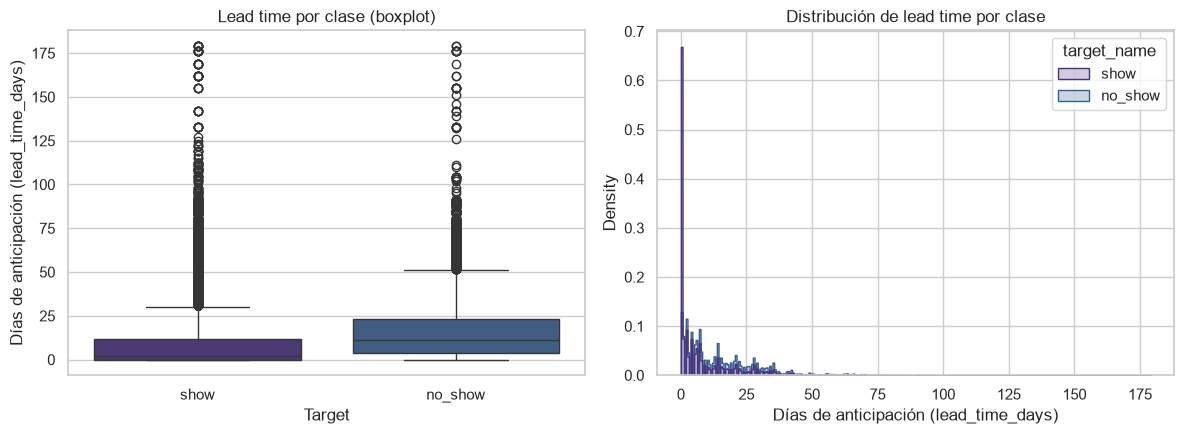

target_name
no_show    11.0
show        2.0
Name: lead_time_days, dtype: float64

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(data=df, x="target_name", y="lead_time_days", hue="target_name", legend=False, ax=axes[0])
axes[0].set_title("Lead time por clase (boxplot)")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Días de anticipación (lead_time_days)")

sns.histplot(data=df, x="lead_time_days", hue="target_name", element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Distribución de lead time por clase")
axes[1].set_xlabel("Días de anticipación (lead_time_days)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "lead_time_vs_noshow.png", dpi=150)
plt.show()

df.groupby("target_name")["lead_time_days"].median()

**Interpretación — anticipación del agendamiento (`lead_time_days`):**

Los turnos con **mayor anticipación** (agendados con más días de antelación) muestran
una mediana de `lead_time_days` más alta entre quienes faltan (`no_show`) que entre
quienes asisten (`show`). Es consistente con la intuición de negocio: cuanto más lejos
en el tiempo se agenda un turno, más chances hay de que surja un imprevisto, se olvide,
o el paciente resuelva la necesidad por otra vía antes de la fecha. Los turnos agendados
el mismo día (`same_day`) tienden a cumplirse casi siempre. Esta variable es, a priori,
una de las señales más accionables: production-wise, sugiere reforzar recordatorios en
turnos agendados con mucha anticipación.


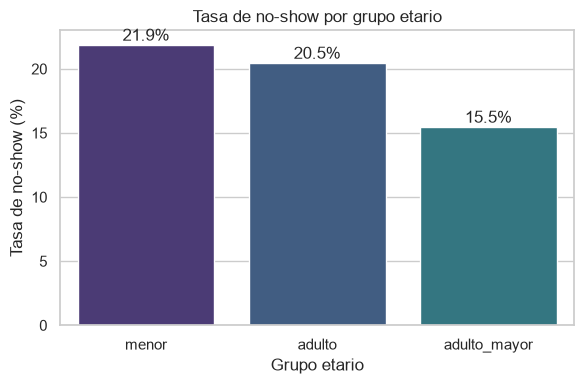

age_group
menor           21.900796
adulto          20.491112
adulto_mayor    15.498924
Name: no_show, dtype: float64

In [13]:
age_group_order = ["menor", "adulto", "adulto_mayor"]
noshow_by_age = df.groupby("age_group", observed=True)["no_show"].mean().reindex(age_group_order) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=noshow_by_age.index, y=noshow_by_age.values, hue=noshow_by_age.index, legend=False, ax=ax)
ax.set_ylabel("Tasa de no-show (%)")
ax.set_xlabel("Grupo etario")
ax.set_title("Tasa de no-show por grupo etario")
for i, v in enumerate(noshow_by_age.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "noshow_by_age_group.png", dpi=150)
plt.show()

noshow_by_age

**Interpretación — edad:**

La tasa de no-show es más alta entre `menor` y `adulto`, y notablemente más baja entre
`adulto_mayor` (65+). Una lectura plausible: los adultos mayores suelen depender más del
sistema de salud (turnos de control por comorbilidades crónicas) y tienen mayor
disponibilidad de tiempo, mientras que los turnos de menores dependen de que un adulto
responsable los traslade, y los adultos en edad laboral compiten con obligaciones
laborales que pueden generar ausencias de último momento.


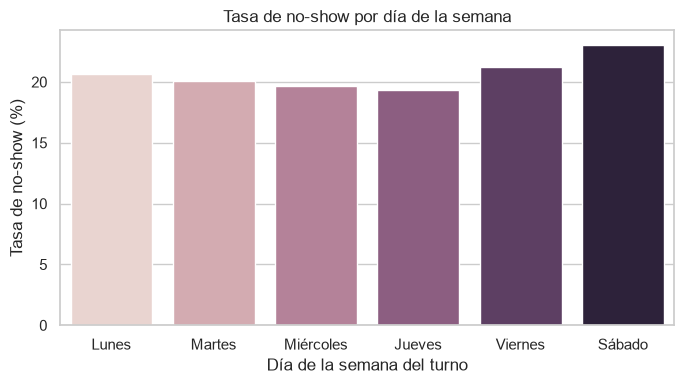

appointment_dow
0    20.644565
1    20.087370
2    19.686074
3    19.349414
4    21.226142
5    23.076923
Name: no_show, dtype: float64

In [14]:
dow_labels = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
noshow_by_dow = df.groupby("appointment_dow")["no_show"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=[dow_labels[i] for i in noshow_by_dow.index], y=noshow_by_dow.values, hue=noshow_by_dow.index, legend=False, ax=ax)
ax.set_ylabel("Tasa de no-show (%)")
ax.set_xlabel("Día de la semana del turno")
ax.set_title("Tasa de no-show por día de la semana")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "noshow_by_dow.png", dpi=150)
plt.show()

noshow_by_dow

**Interpretación — día de la semana:**

La tasa de no-show varía por día de la semana; en este dataset no hay turnos agendados
los domingos (el sistema de salud no opera ese día) y los sábados tienen muy pocos
turnos, por lo que su tasa es más ruidosa (menor soporte estadístico). Entre los días
hábiles, las diferencias son más moderadas, lo que sugiere que el día de la semana es una
señal secundaria frente al lead time y la edad, aunque el modelo la sigue utilizando como
feature adicional.


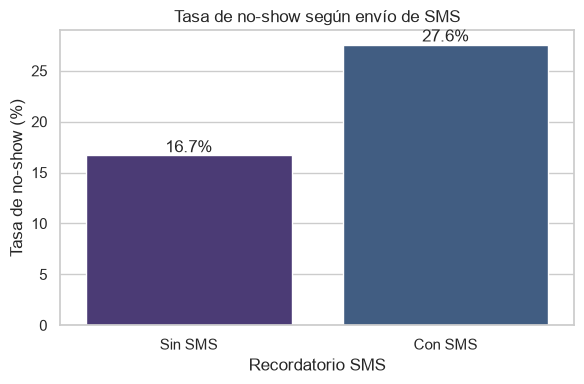

Mediana de lead_time_days según SMS_received:


SMS_received
0     0.0
1    14.0
Name: lead_time_days, dtype: float64

In [15]:
sms_noshow = df.groupby("SMS_received")["no_show"].mean() * 100
sms_lead_time = df.groupby("SMS_received")["lead_time_days"].median()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=sms_noshow.index.map({0: "Sin SMS", 1: "Con SMS"}), y=sms_noshow.values, hue=sms_noshow.index, legend=False, ax=ax)
ax.set_ylabel("Tasa de no-show (%)")
ax.set_xlabel("Recordatorio SMS")
ax.set_title("Tasa de no-show según envío de SMS")
for i, v in enumerate(sms_noshow.values):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sms_effect.png", dpi=150)
plt.show()

print("Mediana de lead_time_days según SMS_received:")
sms_lead_time

**Caveat causal — el efecto del SMS está confundido con el lead time:**

⚠️ A simple vista, los turnos que **recibieron** SMS muestran una tasa de no-show más
**alta**, no más baja. Esto **no significa que el SMS cause más ausentismo**: el sistema
solo envía SMS a turnos agendados con suficiente anticipación (no tiene sentido avisar
por SMS un turno agendado el mismo día), por lo que `SMS_received` está fuertemente
confundido con `lead_time_days` (mediana de lead time muy superior en el grupo que
recibió SMS). Como ya vimos, un mayor lead time se asocia, por sí mismo, a mayor
no-show. Esta correlación espuria es un caso de libro de **correlación ≠ causalidad**, y
se documenta explícitamente para no inducir a la Gerencia a una conclusión errónea del
tipo "hay que sacar el recordatorio por SMS". Para aislar el efecto real del SMS haría
falta un diseño experimental (ej. A/B test) controlando por lead time, fuera del alcance
de este TP.


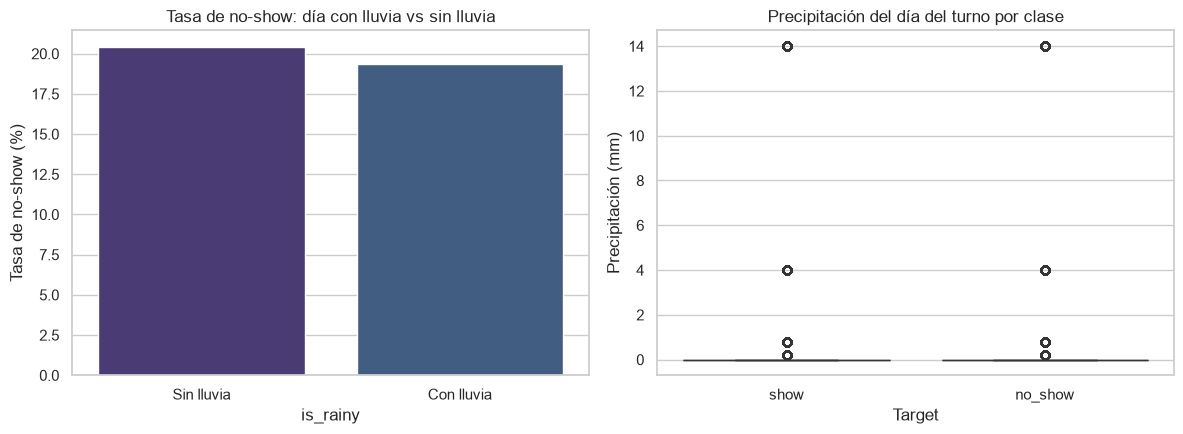

is_rainy
0    20.420644
1    19.379845
Name: no_show, dtype: float64

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

rainy_noshow = df.groupby("is_rainy")["no_show"].mean() * 100
sns.barplot(x=rainy_noshow.index.map({0: "Sin lluvia", 1: "Con lluvia"}), y=rainy_noshow.values, hue=rainy_noshow.index, legend=False, ax=axes[0])
axes[0].set_ylabel("Tasa de no-show (%)")
axes[0].set_title("Tasa de no-show: día con lluvia vs sin lluvia")

sns.boxplot(data=df, x="target_name", y="precipitation_mm", hue="target_name", legend=False, ax=axes[1])
axes[1].set_title("Precipitación del día del turno por clase")
axes[1].set_ylabel("Precipitación (mm)")
axes[1].set_xlabel("Target")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "weather_vs_noshow.png", dpi=150)
plt.show()

rainy_noshow

**Interpretación — clima (fuente secundaria):**

La diferencia en tasa de no-show entre días con y sin lluvia es **pequeña** (unos pocos
puntos porcentuales) y la distribución de precipitación es similar entre las dos clases
en el boxplot. El clima diario agregado por estación aporta una señal débil comparada
con el lead time o la edad; se conserva como feature porque cumple el objetivo de
incorporar una **segunda fuente de datos real** (expectativa superadora del TP) y porque
el `feature_importances_` del Random Forest (Sección 6) permite cuantificar objetivamente
cuánto aporta frente al resto de las variables, en lugar de descartarla a priori.


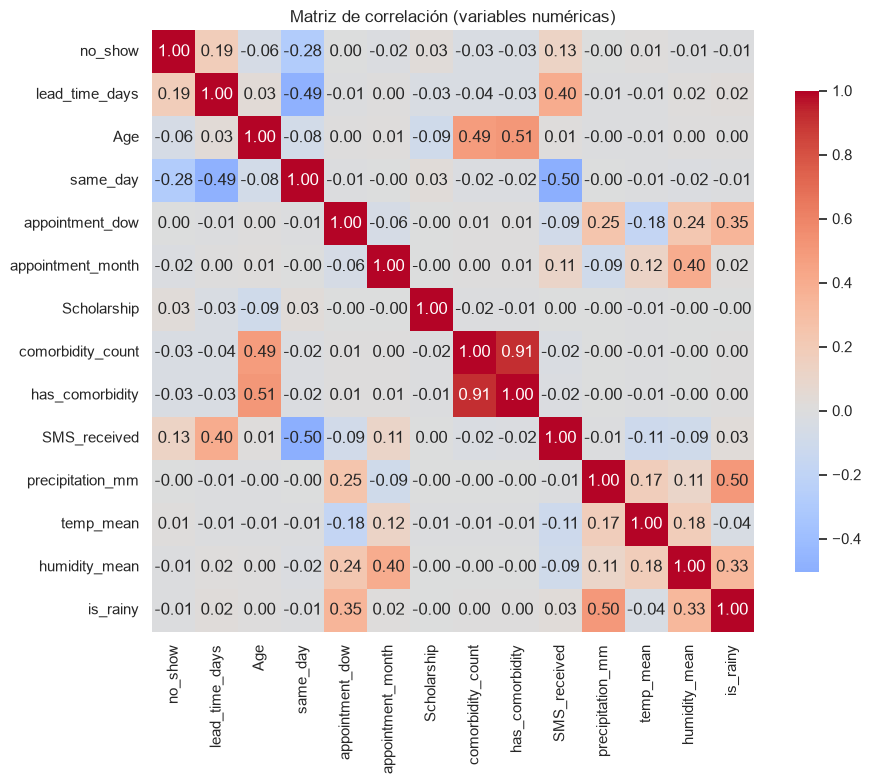

no_show              1.000000
lead_time_days       0.186320
SMS_received         0.126502
Scholarship          0.029166
temp_mean            0.013936
appointment_dow      0.001189
precipitation_mm    -0.002466
humidity_mean       -0.008993
is_rainy            -0.010771
appointment_month   -0.020841
comorbidity_count   -0.030699
has_comorbidity     -0.032672
Age                 -0.060320
same_day            -0.283446
Name: no_show, dtype: float64

In [17]:
numeric_cols_corr = [
    "no_show", "lead_time_days", "Age", "same_day", "appointment_dow",
    "appointment_month", "Scholarship", "comorbidity_count", "has_comorbidity",
    "SMS_received", "precipitation_mm", "temp_mean", "humidity_mean", "is_rainy",
]
corr = df[numeric_cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de correlación (variables numéricas)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

corr["no_show"].sort_values(ascending=False)

**Interpretación — matriz de correlación:**

Ninguna variable numérica individual tiene una correlación lineal fuerte con `no_show`
(todas por debajo de ~0,2 en valor absoluto), lo cual es esperable en un problema de
comportamiento humano con múltiples factores débiles. `lead_time_days` y `same_day` son
las que más correlación (en valor absoluto) muestran con el target, coherente con el
storytelling anterior. Esto también justifica el uso de un modelo no lineal basado en
árboles (Decision Tree / Random Forest), capaz de capturar interacciones entre variables
que una correlación lineal par a par no puede ver.


## 5. Modelado

Se reutiliza `noshow.train.train_models`, que:

1. Separa `X` (features) / `y` (target `no_show`) con
   `noshow.preprocess.split_features_target`.
2. Hace un split hold-out **estratificado** 80/20 (`train_test_split(..., stratify=y,
   random_state=42)`).
3. Entrena un **Árbol de Decisión podado** (`max_depth=6`, `min_samples_leaf=50`) y un
   **Random Forest sin podar** (`n_estimators=300`, `max_depth=12`,
   `min_samples_leaf=5`, `max_features="sqrt"`), cada uno con su propio
   `ColumnTransformer` (One-Hot de `Gender`/`age_group`/`neighbourhood_grouped`, sin
   escalado — los árboles no lo requieren) ajustado **solo sobre train** (sin fuga).
4. Compara ambos modelos con `StratifiedKFold(n_splits=5)` sobre train (F1 y ROC-AUC,
   media ± desvío estándar entre folds).
5. Elige el modelo final por **ROC-AUC de CV** (más robusto que F1 a 0,5 bajo el
   desbalance ~80/20) y reserva el hold-out de test exclusivamente para la evaluación
   final (Sección 6).


In [18]:
from noshow.preprocess import split_features_target
from noshow.train import train_models

X, y = split_features_target(df)
print(f"X: {X.shape}   y: {y.shape}   tasa de no_show en y: {y.mean():.3f}")

result = train_models(df)
X_train, X_test, y_train, y_test = result["X_train"], result["X_test"], result["y_train"], result["y_test"]
print(f"\nModelo elegido por validación cruzada: {result['best_model']}")

X: (110521, 23)   y: (110521,)   tasa de no_show en y: 0.202



Modelo elegido por validación cruzada: random_forest


In [19]:
cv_table = pd.DataFrame(result["cv_results"]).T
cv_table["f1"] = cv_table.apply(lambda r: f"{r['f1_mean']:.3f} ± {r['f1_std']:.3f}", axis=1)
cv_table["roc_auc"] = cv_table.apply(lambda r: f"{r['roc_auc_mean']:.3f} ± {r['roc_auc_std']:.3f}", axis=1)
cv_table[["f1", "roc_auc"]]

,f1,roc_auc
decision_tree,0.016 ± 0.008,0.726 ± 0.004
random_forest,0.001 ± 0.001,0.739 ± 0.003


**Interpretación — comparación por validación cruzada:**

El Random Forest supera al Árbol de Decisión en **ROC-AUC** (mejor capacidad de
ranking/discriminación entre folds), por lo que es el modelo elegido para la evaluación
final. El **F1 medido al umbral por defecto de 0,5** es muy bajo para ambos modelos —
esto es un artefacto esperable del desbalance ~80/20 combinado con un umbral que no está
calibrado al costo de negocio: a 0,5, ambos modelos casi no se animan a predecir la clase
minoritaria. El ROC-AUC evita ese problema porque evalúa el ranking de probabilidades en
todos los umbrales posibles, y es el criterio de selección adecuado; el ajuste de umbral
orientado a recall se aborda explícitamente en la Sección 6 (`threshold_analysis`), que
es donde el F1 vuelve a ser una métrica útil.


## 6. Evaluación

Se evalúa el modelo elegido (Random Forest) sobre el **hold-out de test**, nunca visto
durante el entrenamiento ni la validación cruzada.


In [20]:
from IPython.display import Image, display
from noshow.evaluate import (
    evaluate_model,
    threshold_analysis,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importances,
    plot_decision_tree,
    export_decision_tree_text,
)

pipeline = result["pipeline"]
eval_metrics = evaluate_model(pipeline, X_test, y_test)

report_df = pd.DataFrame(eval_metrics["classification_report"]).T
report_df

,precision,recall,f1-score,support
0,0.798145,0.999830,0.887676,17642.000000
1,0.400000,0.000448,0.000895,4463.000000
accuracy,0.798055,0.798055,0.798055,0.798055
macro avg,0.599072,0.500139,0.444285,22105.000000
weighted avg,0.717759,0.798055,0.708635,22105.000000


**Lectura del `classification_report`:**

La fila `1` corresponde a la clase de interés (`no_show`). Al umbral por defecto (0,5),
el recall de `no_show` es bajo: el modelo es conservador y solo marca como "no-show" los
casos donde está muy seguro, dejando pasar muchos no-show reales (falsos negativos). Esto
motiva el ajuste de umbral que se hace más abajo con `threshold_analysis`.


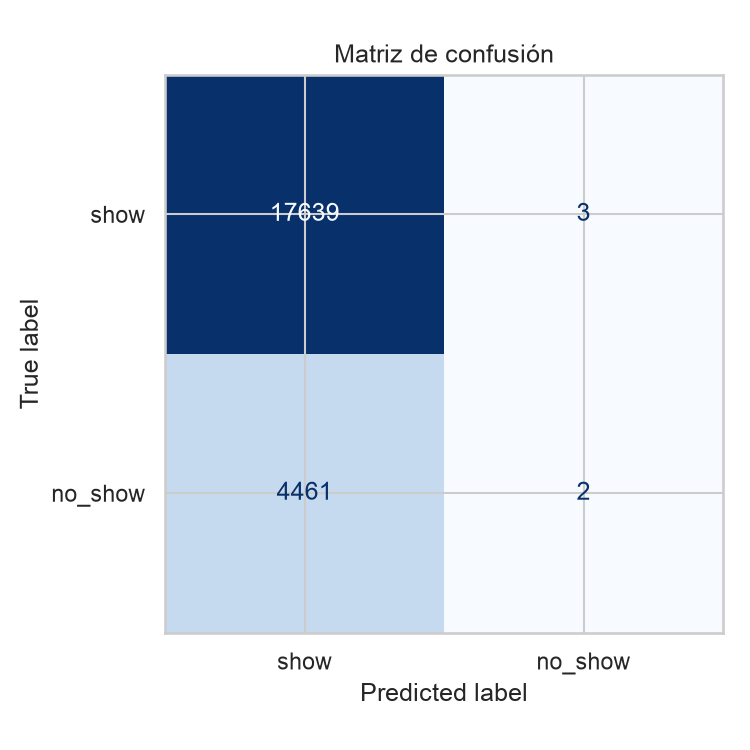

array([[17639,     3],
       [ 4461,     2]])

In [21]:
cm_path = plot_confusion_matrix(eval_metrics["confusion_matrix"])
display(Image(filename=str(cm_path)))
eval_metrics["confusion_matrix"]

**Interpretación — matriz de confusión y costo FN vs FP:**

- **Falso Negativo (FN)**: el modelo predice "show" pero el paciente falta. Costo alto:
  la franja del profesional queda ociosa sin que se haya tomado ninguna acción
  preventiva ni se haya podido reasignar el turno a otro paciente en lista de espera.
- **Falso Positivo (FP)**: el modelo predice "no_show" pero el paciente sí asiste. Costo
  bajo: en el peor caso se envió un recordatorio de más (o se ofreció un sobreturno que
  termina en una sala algo más ocupada de lo esperado), pero no se pierde la atención.

Dado que el costo de un FN es sustancialmente mayor que el de un FP, el criterio de
negocio prioriza **recall** de la clase `no_show` sobre precision, incluso a costa de
generar más falsos positivos (más recordatorios/sobreturnos de los estrictamente
necesarios). Esto es lo que motiva bajar el umbral de decisión respecto del 0,5 por
defecto (ver `threshold_analysis` más abajo).


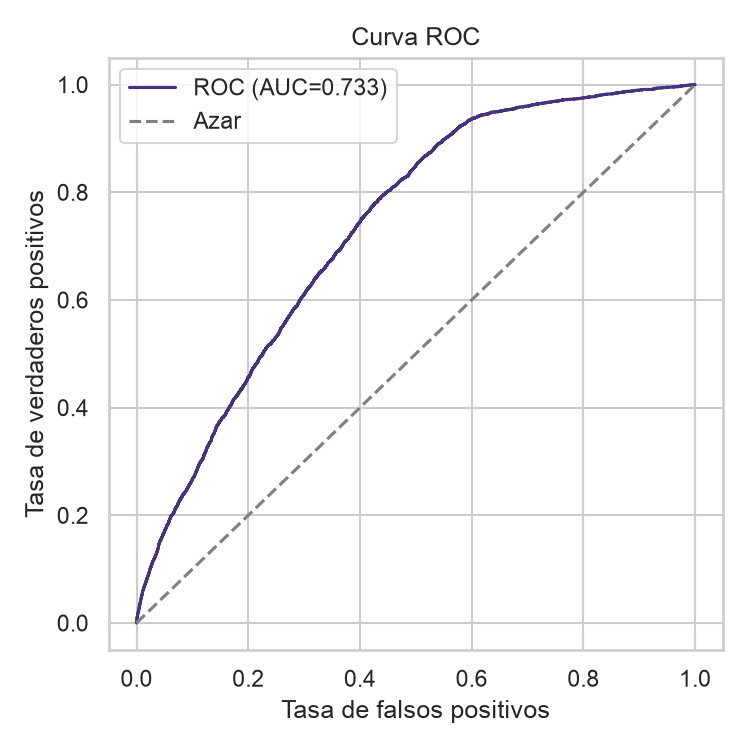

ROC-AUC (hold-out de test): 0.733


In [22]:
roc_path = plot_roc_curve(eval_metrics["roc_curve"]["fpr"], eval_metrics["roc_curve"]["tpr"], eval_metrics["roc_auc"])
display(Image(filename=str(roc_path)))
print(f"ROC-AUC (hold-out de test): {eval_metrics['roc_auc']:.3f}")

**Interpretación — curva ROC:**

Un ROC-AUC de test en torno a **0,73** indica que el modelo discrimina razonablemente
bien entre quienes van a faltar y quienes no (0,5 sería equivalente al azar, 1,0 sería
un clasificador perfecto). No es un modelo de altísima precisión, pero sí lo
suficientemente informativo como para **priorizar recursos limitados** (llamados,
sobreturnos) hacia los turnos de mayor riesgo relativo, que es exactamente el caso de uso
de negocio planteado en la Sección 1.


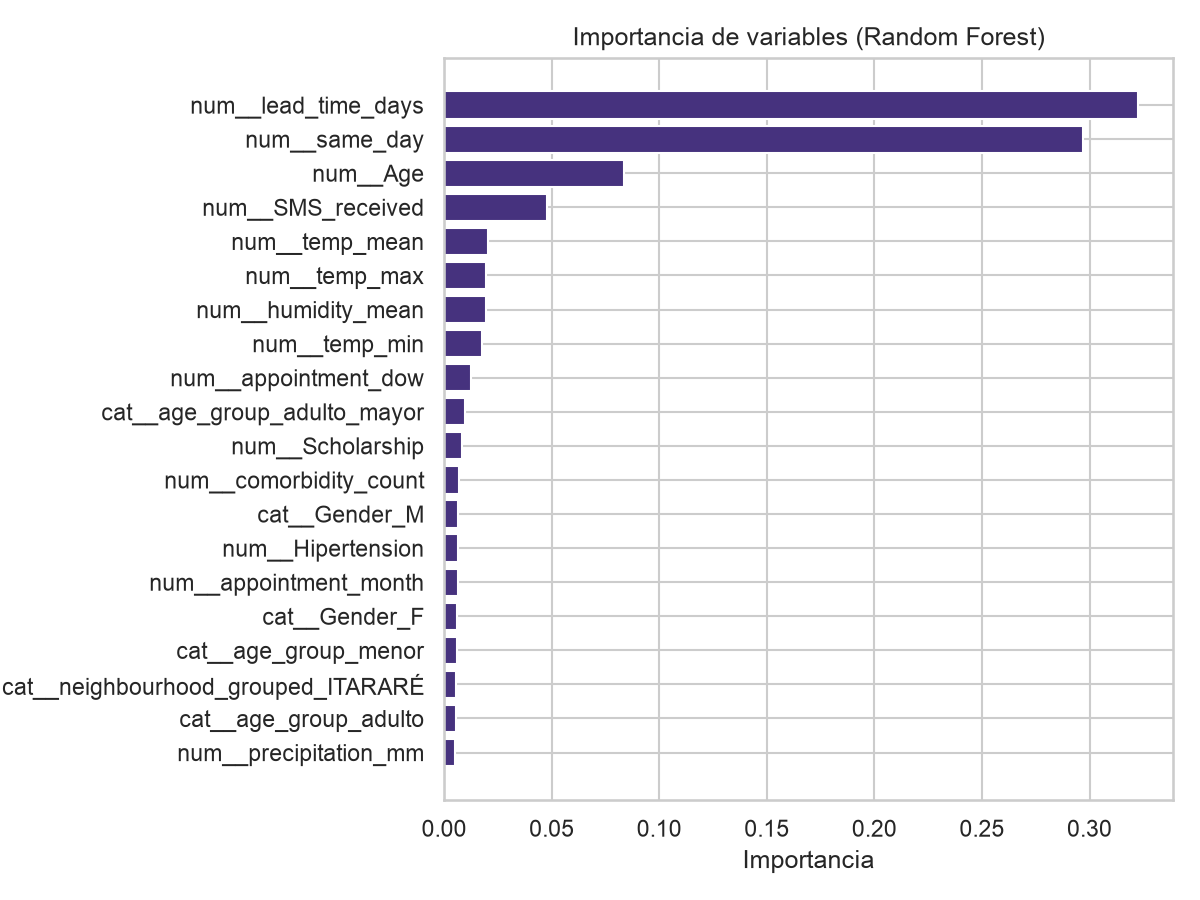

In [23]:
fi_path = plot_feature_importances(pipeline)
display(Image(filename=str(fi_path)))

**Interpretación — importancia de variables (Random Forest):**

`lead_time_days` y `same_day` encabezan el ranking de importancia, confirmando el
hallazgo del EDA (Sección 4): la anticipación con la que se agenda el turno es, por
lejos, la señal más fuerte. La edad y algunas categorías de barrio también aportan;
las variables de clima (`precipitation_mm`, `temp_mean`, `humidity_mean`, `is_rainy`)
aparecen con importancia baja pero no nula, consistente con la lectura de "señal débil"
del EDA.


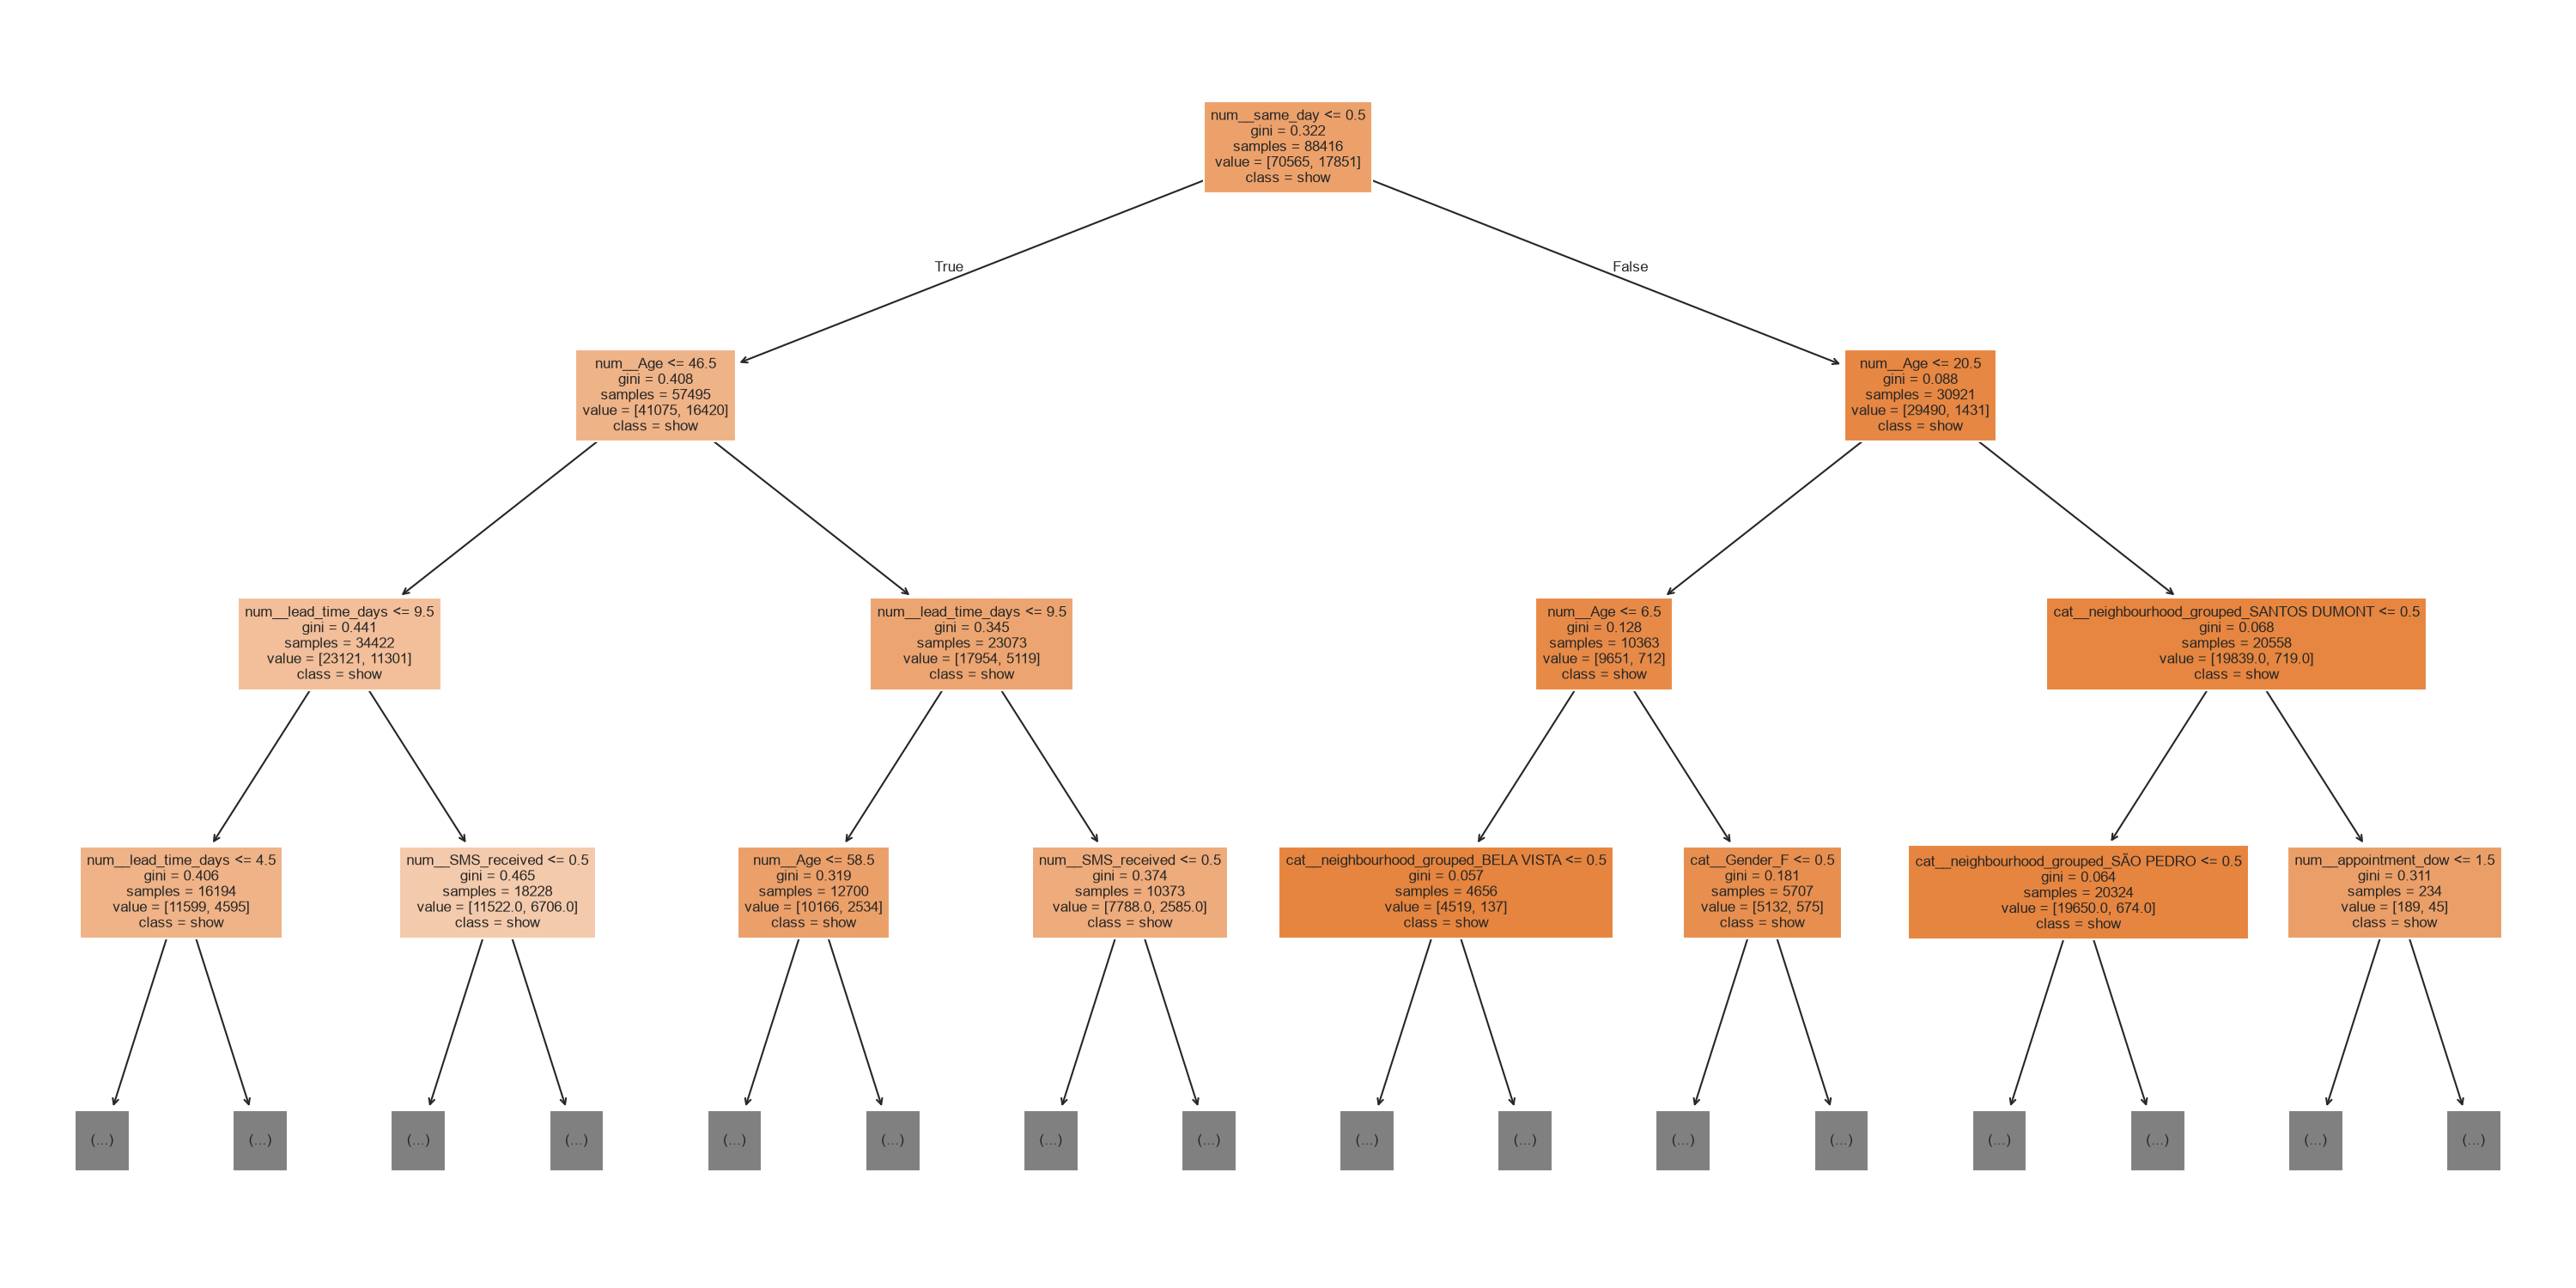

|--- num__same_day <= 0.50
|   |--- num__Age <= 46.50
|   |   |--- num__lead_time_days <= 9.50
|   |   |   |--- num__lead_time_days <= 4.50
|   |   |   |   |--- num__temp_max <= 33.60
|   |   |   |   |   |--- num__Alcoholism <= 0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- num__Alcoholism >  0.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__temp_max >  33.60
|   |   |   |   |   |--- num__Age <= 18.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- num__Age >  18.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- num__lead_time_days >  4.50
|   |   |   |   |--- num__Age <= 12.50
|   |   |   |   |   |--- num__temp_max <= 33.60
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- num__temp_max >  33.60
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__Age >  12.50
|   |   |   |   |   |--- num__Age <= 30.50
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- num__Age >  30.50
|   |   |   |   |

In [24]:
dt_pipeline = result["pipelines"]["decision_tree"]
dt_path = plot_decision_tree(dt_pipeline, max_depth=3)
display(Image(filename=str(dt_path)))
print(export_decision_tree_text(dt_pipeline)[:2000])

**Interpretación — Árbol de Decisión (interpretabilidad):**

El árbol podado (profundidad máxima 6, graficado hasta profundidad 3 por legibilidad)
confirma que sus primeros splits usan `lead_time_days`/`same_day`, igual que el ranking
de importancia del Random Forest — dos modelos independientes coinciden en la señal
principal, lo cual da confianza adicional al hallazgo. La poda (`max_depth`,
`min_samples_leaf=50`) es necesaria porque un árbol sin restricciones sobre ~110 mil
filas memoriza el ruido del training set (overfitting: alta métrica en train, mucho
peor en test); el Random Forest, al promediar muchos árboles no podados sobre muestras y
subconjuntos de variables distintos, compensa ese sobreajuste sin necesitar podar cada
árbol individualmente — por eso termina generalizando mejor (mayor ROC-AUC de test).


In [25]:
y_proba_test = pipeline.predict_proba(X_test)[:, 1]

# Se agregan umbrales intermedios (0.15/0.22/0.25/0.28) a los de DEFAULT_THRESHOLDS para
# poder ubicar con precisión el punto 0.25 discutido en la interpretación de abajo.
from noshow.evaluate import DEFAULT_THRESHOLDS

extra_thresholds = sorted(set(DEFAULT_THRESHOLDS) | {0.15, 0.22, 0.25, 0.28})
table = threshold_analysis(y_test, y_proba_test, thresholds=extra_thresholds)
table

,threshold,precision,recall,f1
0,0.10,0.280742,0.939727,0.432327
1,0.15,0.285007,0.928075,0.436092
2,0.20,0.295601,0.874748,0.441879
3,0.22,0.305811,0.820748,0.445593
4,0.25,0.322510,0.721040,0.445676
5,0.28,0.344026,0.583912,0.432962
6,0.30,0.365321,0.468295,0.410448
7,0.40,0.592593,0.039435,0.073950
8,0.50,0.400000,0.000448,0.000895
9,0.60,0.000000,0.000000,0.000000


In [26]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(table["threshold"], table["precision"], marker="o", label="Precision")
ax.plot(table["threshold"], table["recall"], marker="o", label="Recall")
ax.plot(table["threshold"], table["f1"], marker="o", label="F1")
ax.axvline(0.25, linestyle="--", color="gray", label="Umbral orientado a recall (0.25)")
ax.axvline(config.RISK_LOW, linestyle=":", color="firebrick", label=f"RISK_LOW de negocio ({config.RISK_LOW})")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Métrica (clase no_show)")
ax.set_title("Precision / Recall / F1 según umbral de decisión")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "threshold_analysis.png", dpi=150)
plt.show()

table.loc[table["threshold"] == 0.25]

/var/folders/tc/xyydm9hj0n91z_w_s5p_6zdw0000gn/T/ipykernel_62254/716571103.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


,threshold,precision,recall,f1
4,0.25,0.32251,0.72104,0.445676


**Interpretación — ajuste de umbral orientado a recall:**

Bajando el umbral de decisión de 0,5 a **0,25**, el **recall de `no_show` sube
marcadamente a ≈0,72** (F1≈0,45) a costa de una precision más baja: el modelo pasa a
detectar mucho más no-show real, aunque también genera más falsos positivos. Como se
justificó en la lectura de la matriz de confusión, este intercambio es **deseable dado
el costo asimétrico** (FN mucho más caro que FP): la Gerencia prefiere reforzar el
recordatorio o dejar planificado un sobreturno de más, antes que perder una franja que
termina vacía sin aviso previo. Este umbral orientado a recall (0,25) queda apenas por
debajo de la banda `RISK_LOW=0.3` configurada en `noshow.config` (que la app de
Streamlit usa para separar "sin acción" de "recordatorio SMS") — ambos números son
coherentes entre sí y reflejan la misma decisión de negocio: **preferir sobre-actuar
(más recordatorios) a dejar pasar un no-show real**.


## 7. Conclusión

### Coherencia hipótesis ↔ resultado

La hipótesis de trabajo (Sección 1) planteaba que el no-show no es aleatorio y que
variables observables al agendar el turno permiten estimar su probabilidad con una
capacidad de discriminación útil. Los resultados la sostienen: el Random Forest alcanza
un **ROC-AUC de test ≈0,73**, muy por encima del azar (0,5), y el ranking de
`feature_importances_` coincide con lo hallado en el EDA (`lead_time_days`/`same_day` y
edad como señales principales), lo cual da consistencia interna al análisis. La segunda
fuente de datos (clima, estación A612) se integró correctamente al pipeline pero aporta
una señal débil frente al comportamiento del paciente — un hallazgo honesto, no un
fracaso: confirma qué variables merecen la inversión de negocio (recordatorios por
lead time) y cuáles no (no vale la pena condicionar la política de sobreturnos al
pronóstico del tiempo).

### Valor de negocio

Con el umbral orientado a recall (~0,25), el modelo detecta ≈72 % de los no-show reales
del hold-out de test (4.463 casos), es decir, identifica con antelación
**≈3.213 turnos** que efectivamente iban a resultar en ausencia (72 % de 4.463), sobre
los cuales la institución puede accionar (recordatorio reforzado o sobreturno) antes de
que la franja quede vacía sin aviso. Usando el costo de referencia de
`noshow.config.COST_HOUR` (una franja horaria ociosa) como proxy conservador, cada
no-show anticipado y compensado con un sobreturno representa una hora-profesional que
antes se perdía y ahora se recupera — la magnitud exacta de horas recuperadas depende de
qué fracción de esos turnos de alto riesgo termina efectivamente cubierta con un
sobreturno, una decisión operativa fuera del alcance de este modelo pero que la app de
Streamlit permite estimar de forma interactiva variando el umbral y el modo lote (agenda
del día).

### Limitaciones

- **Los datos son de 2016**, de una única ciudad (Vitória, ES, Brasil) y **pre-COVID**:
  los patrones de asistencia a salud pueden haber cambiado estructuralmente (telesalud,
  nuevos hábitos post-pandemia), por lo que el modelo **no debe usarse tal cual en otra
  geografía o período** sin revalidar.
- **Concept drift**: aun dentro de la misma institución, los factores que explican el
  no-show cambian con el tiempo (estacionalidad, políticas de turnos, composición
  socioeconómica de los pacientes). El modelo debería **reentrenarse periódicamente**
  con datos recientes, y monitorearse su ROC-AUC/recall en producción para detectar
  degradación.
- **La ventana de clima es acotada** (2016-04-29 a 2016-06-08, la cobertura real de
  turnos), lo que limita la variabilidad climática observada (por ejemplo, no hay datos
  de estaciones frías/calurosas extremas de otras épocas del año).
- **El efecto de `SMS_received` está confundido con `lead_time_days`** (Sección 4): no
  se puede concluir causalmente si el SMS reduce o aumenta el no-show sin un diseño
  experimental controlado.
- Es un modelo **académico** (TPO), no un sistema desplegado en producción: no hay
  monitoreo continuo, reentrenamiento automático, ni validación en un entorno real con
  retroalimentación de los propios recordatorios/sobreturnos aplicados.
